# Clasificación de Enfermedades en Plantas con Deep Learning

Proyecto de clasificación de imágenes usando PyTorch y Transfer Learning,
para identificar enfermedades en hojas de cultivos usando el dataset PlantVillage.

**Autor:** Joel Velasquez
**Dataset:** PlantVillage (Kaggle)
**Framework:** PyTorch

In [ ]:
import torch
print("GPU disponible:", torch.cuda.is_available())
print("Dispositivo:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU disponible: True
Dispositivo: Tesla T4


## 1. Configuración de Kaggle y descarga del dataset

Necesitamos conectar Colab con Kaggle para descargar PlantVillage directamente.

In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"joelvelsquez","key":"a1d515e846654a886ecc1b70b11fde9a"}'}

In [6]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d plant_data

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:04<00:00, 154MB/s]



In [8]:
import os
print(os.listdir('plant_data'))
print(os.listdir('plant_data/PlantVillage'))

['plantvillage', 'PlantVillage']
['Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato_Bacterial_spot', 'Pepper__bell___healthy', 'Tomato_Late_blight', 'Tomato_healthy', 'Pepper__bell___Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Potato___healthy', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Potato___Early_blight', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato_Leaf_Mold', 'Potato___Late_blight']


## 2. Exploración del Dataset

Visualizamos algunas imágenes de muestra para entender los datos con los que vamos a trabajar.

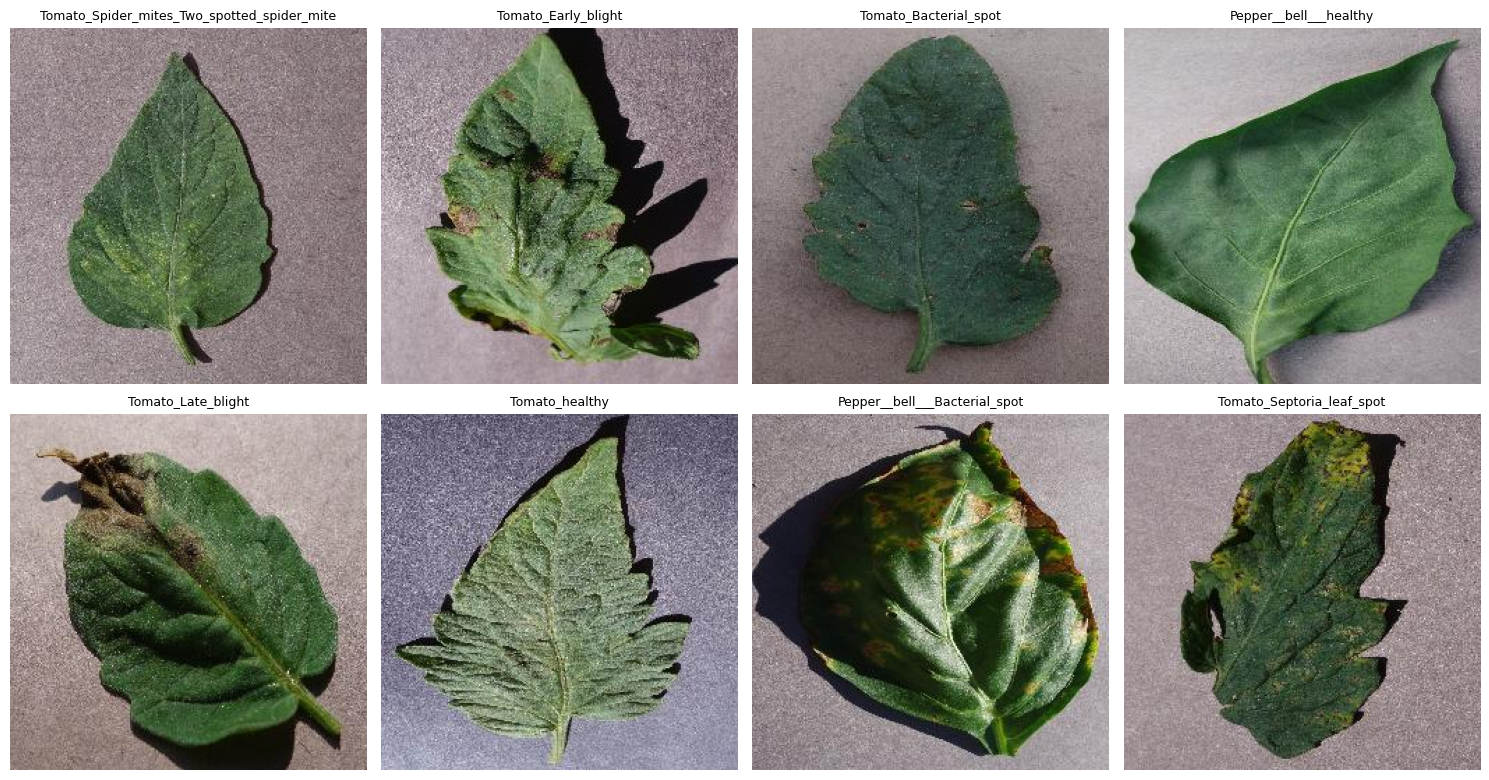

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import os

base_dir = 'plant_data/PlantVillage'
clases = os.listdir(base_dir)

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i in range(8):
    clase = clases[i]
    carpeta = os.path.join(base_dir, clase)
    imagen_nombre = os.listdir(carpeta)[0]
    img = Image.open(os.path.join(carpeta, imagen_nombre))

    axes[i].imshow(img)
    axes[i].set_title(clase, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 3. Preparación de datos: Transformaciones y división Train/Test

Antes de entrenar, necesitamos:
- Redimensionar las imágenes a un tamaño fijo
- Normalizar los valores de píxeles
- Dividir el dataset en entrenamiento (80%) y validación (20%)

In [10]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

# Transformaciones: redimensionar y normalizar
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Cargar el dataset completo
dataset_completo = datasets.ImageFolder('plant_data/PlantVillage', transform=transform)

# Dividir en 80% entrenamiento, 20% validación
total = len(dataset_completo)
train_size = int(0.8 * total)
val_size = total - train_size

train_dataset, val_dataset = random_split(dataset_completo, [train_size, val_size])

print(f"Total de imágenes: {total}")
print(f"Entrenamiento: {len(train_dataset)}")
print(f"Validación: {len(val_dataset)}")
print(f"Clases: {dataset_completo.classes}")

Total de imágenes: 20638
Entrenamiento: 16510
Validación: 4128
Clases: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


## 3.1 Data Augmentation

Para mejorar la generalización del modelo, aplicamos transformaciones
aleatorias a las imágenes de entrenamiento (rotación, volteo, cambios de brillo).
Esto ayuda a que el modelo no memorice posiciones exactas y sea más robusto.

In [11]:
from torchvision import datasets, transforms
import torch
from torch.utils.data import random_split, DataLoader

# Transformaciones para ENTRENAMIENTO (con augmentation)
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones para VALIDACIÓN (sin augmentation, solo normalizar)
val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Cargar el dataset completo (sin transform aún)
dataset_completo = datasets.ImageFolder('plant_data/PlantVillage')

total = len(dataset_completo)
train_size = int(0.8 * total)
val_size = total - train_size

train_dataset, val_dataset = random_split(dataset_completo, [train_size, val_size])

# Aplicar transformaciones distintas a cada subset
train_dataset.dataset.transform = None  # se asigna por separado abajo
train_dataset = torch.utils.data.Subset(
    datasets.ImageFolder('plant_data/PlantVillage', transform=train_transform),
    train_dataset.indices
)
val_dataset = torch.utils.data.Subset(
    datasets.ImageFolder('plant_data/PlantVillage', transform=val_transform),
    val_dataset.indices
)

print(f"Entrenamiento: {len(train_dataset)}")
print(f"Validación: {len(val_dataset)}")
print(f"Clases: {dataset_completo.classes}")

Entrenamiento: 16510
Validación: 4128
Clases: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


## 4. Definición del modelo: Transfer Learning con ResNet18

Usamos ResNet18 preentrenado en ImageNet y adaptamos la última capa
para clasificar nuestras 15 clases de plantas.

In [15]:
from torchvision import models
import torch.nn as nn

# Cargar ResNet18 preentrenado
modelo = models.resnet18(weights='IMAGENET1K_V1')

# Congelar TODAS las capas primero
for param in modelo.parameters():
    param.requires_grad = False

# Descongelar las últimas capas (layer4) para fine-tuning
for param in modelo.layer4.parameters():
    param.requires_grad = True

# Reemplazar la última capa para clasificar 15 clases
num_clases = len(dataset_completo.classes)
modelo.fc = nn.Linear(modelo.fc.in_features, num_clases)

# Mover a GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo = modelo.to(device)

print(modelo.fc)
print("Parámetros entrenables:", sum(p.numel() for p in modelo.parameters() if p.requires_grad))

Linear(in_features=512, out_features=15, bias=True)
Parámetros entrenables: 8401423


## 5. Configuración del entrenamiento

Definimos la función de pérdida (loss function) y el optimizador,
que son los encargados de medir el error y ajustar los pesos.

In [16]:
import torch.optim as optim

# Función de pérdida: mide qué tan equivocado está el modelo
criterio = nn.CrossEntropyLoss()

# Optimizador: ajusta los pesos para reducir el error (solo entrena la última capa)
optimizador = optim.Adam(
    [p for p in modelo.parameters() if p.requires_grad],
    lr=0.0001  # learning rate más bajo porque ahora hay más capas entrenando
)

# DataLoaders: cargan los datos en lotes (batches) para entrenar
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Configuración lista")
print(f"Lotes de entrenamiento: {len(train_loader)}")
print(f"Lotes de validación: {len(val_loader)}")

Configuración lista
Lotes de entrenamiento: 516
Lotes de validación: 129


## 6. Entrenamiento del modelo

Entrenamos el modelo durante varias épocas (epochs).
En cada época, el modelo ve todas las imágenes de entrenamiento,
calcula su error y ajusta los pesos mediante backpropagation.

In [17]:
import time

num_epocas = 10
historial = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoca in range(num_epocas):
    inicio = time.time()

    # ---- Entrenamiento ----
    modelo.train()
    perdida_train = 0

    for imagenes, etiquetas in train_loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)

        optimizador.zero_grad()
        salidas = modelo(imagenes)
        perdida = criterio(salidas, etiquetas)
        perdida.backward()
        optimizador.step()

        perdida_train += perdida.item()

    # ---- Validación ----
    modelo.eval()
    perdida_val = 0
    correctas = 0
    total = 0

    with torch.no_grad():
        for imagenes, etiquetas in val_loader:
            imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
            salidas = modelo(imagenes)
            perdida = criterio(salidas, etiquetas)
            perdida_val += perdida.item()

            _, predicciones = torch.max(salidas, 1)
            correctas += (predicciones == etiquetas).sum().item()
            total += etiquetas.size(0)

    acc = 100 * correctas / total
    tiempo = time.time() - inicio

    historial['train_loss'].append(perdida_train/len(train_loader))
    historial['val_loss'].append(perdida_val/len(val_loader))
    historial['val_acc'].append(acc)

    print(f"Época {epoca+1}/{num_epocas} - "
          f"Train Loss: {perdida_train/len(train_loader):.4f} - "
          f"Val Loss: {perdida_val/len(val_loader):.4f} - "
          f"Val Acc: {acc:.2f}% - "
          f"Tiempo: {tiempo:.1f}s")

Época 1/10 - Train Loss: 0.4668 - Val Loss: 0.1703 - Val Acc: 94.53% - Tiempo: 64.5s
Época 2/10 - Train Loss: 0.1607 - Val Loss: 0.1206 - Val Acc: 95.93% - Tiempo: 62.4s
Época 3/10 - Train Loss: 0.1091 - Val Loss: 0.1063 - Val Acc: 96.46% - Tiempo: 62.5s
Época 4/10 - Train Loss: 0.0807 - Val Loss: 0.0680 - Val Acc: 97.84% - Tiempo: 62.5s
Época 5/10 - Train Loss: 0.0630 - Val Loss: 0.0653 - Val Acc: 97.58% - Tiempo: 62.2s
Época 6/10 - Train Loss: 0.0627 - Val Loss: 0.0640 - Val Acc: 97.87% - Tiempo: 62.4s
Época 7/10 - Train Loss: 0.0461 - Val Loss: 0.0452 - Val Acc: 98.38% - Tiempo: 62.7s
Época 8/10 - Train Loss: 0.0471 - Val Loss: 0.0763 - Val Acc: 97.36% - Tiempo: 62.5s
Época 9/10 - Train Loss: 0.0401 - Val Loss: 0.0588 - Val Acc: 97.97% - Tiempo: 62.2s
Época 10/10 - Train Loss: 0.0384 - Val Loss: 0.0503 - Val Acc: 98.33% - Tiempo: 62.6s


## 7. Guardar el modelo y visualizar resultados

In [18]:
torch.save(modelo.state_dict(), 'modelo_plantvillage.pth')
print("Modelo guardado correctamente")

Modelo guardado correctamente


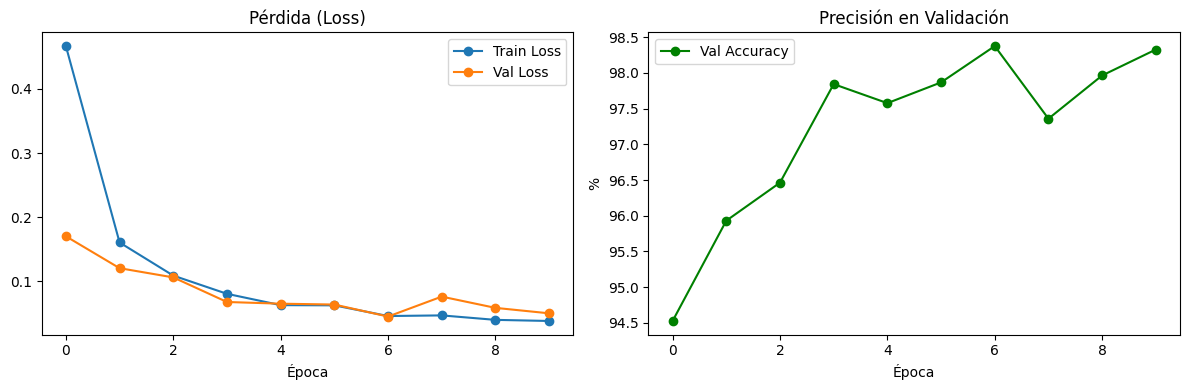

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(historial['train_loss'], label='Train Loss', marker='o')
ax[0].plot(historial['val_loss'], label='Val Loss', marker='o')
ax[0].set_title('Pérdida (Loss)')
ax[0].set_xlabel('Época')
ax[0].legend()

ax[1].plot(historial['val_acc'], label='Val Accuracy', marker='o', color='green')
ax[1].set_title('Precisión en Validación')
ax[1].set_xlabel('Época')
ax[1].set_ylabel('%')
ax[1].legend()

plt.tight_layout()
plt.savefig('grafico_entrenamiento.png')
plt.show()

## 8. Predicciones sobre imágenes de validación

Visualizamos ejemplos reales: la imagen, la predicción del modelo
y la etiqueta verdadera.

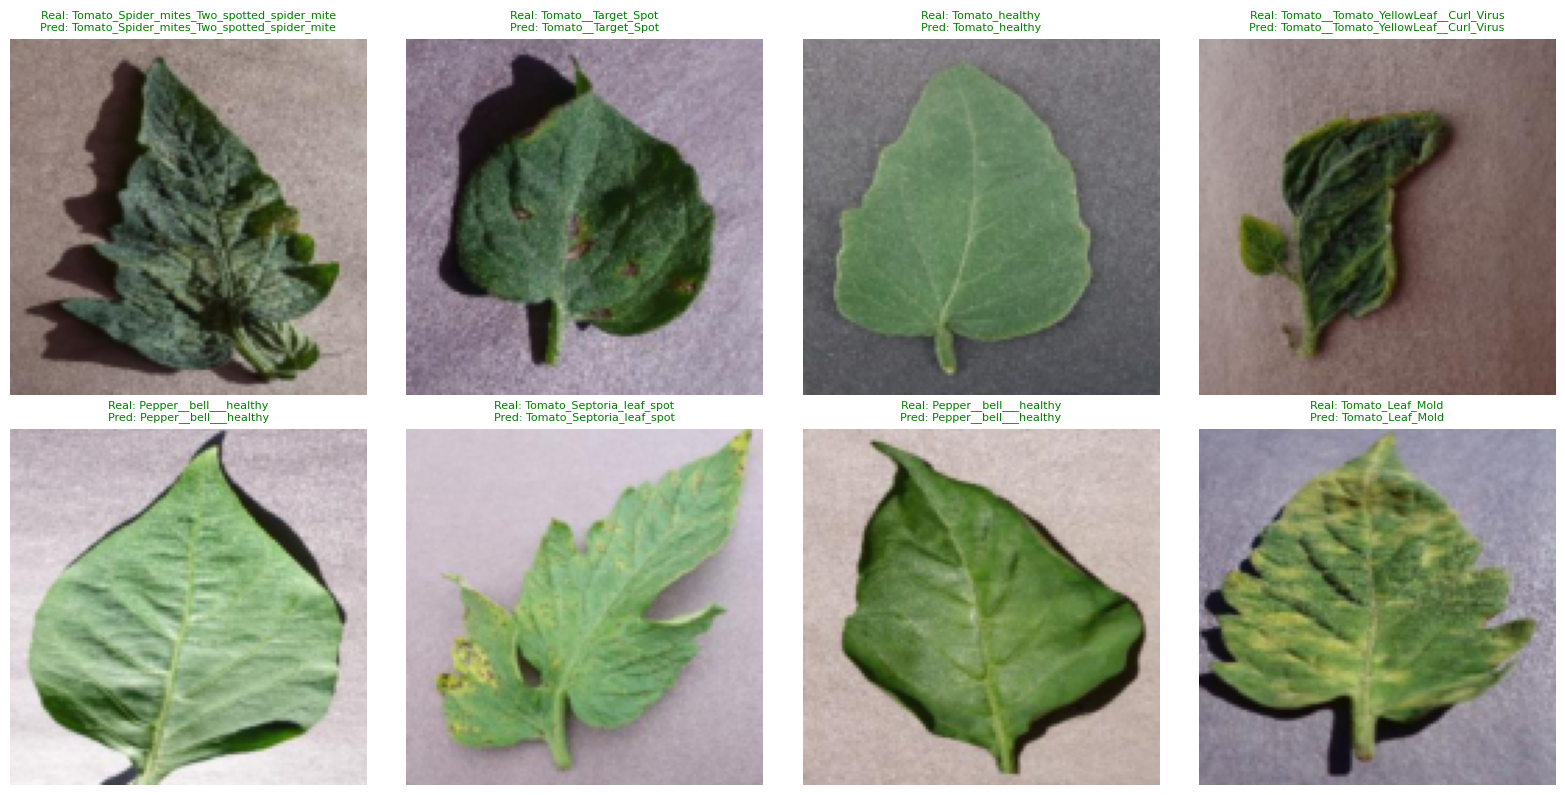

In [20]:
import numpy as np

# Función para revertir la normalización y mostrar la imagen
def desnormalizar(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

modelo.eval()
imagenes, etiquetas = next(iter(val_loader))
imagenes_gpu = imagenes.to(device)

with torch.no_grad():
    salidas = modelo(imagenes_gpu)
    _, predicciones = torch.max(salidas, 1)

clases = dataset_completo.classes

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    img = desnormalizar(imagenes[i])
    pred = clases[predicciones[i].cpu()]
    real = clases[etiquetas[i]]

    color = 'green' if pred == real else 'red'

    axes[i].imshow(img)
    axes[i].set_title(f"Real: {real}\nPred: {pred}", fontsize=8, color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('predicciones_ejemplo.png')
plt.show()

## 9. Matriz de Confusión

Evaluamos el modelo sobre todo el conjunto de validación para ver
en qué clases se confunde más.

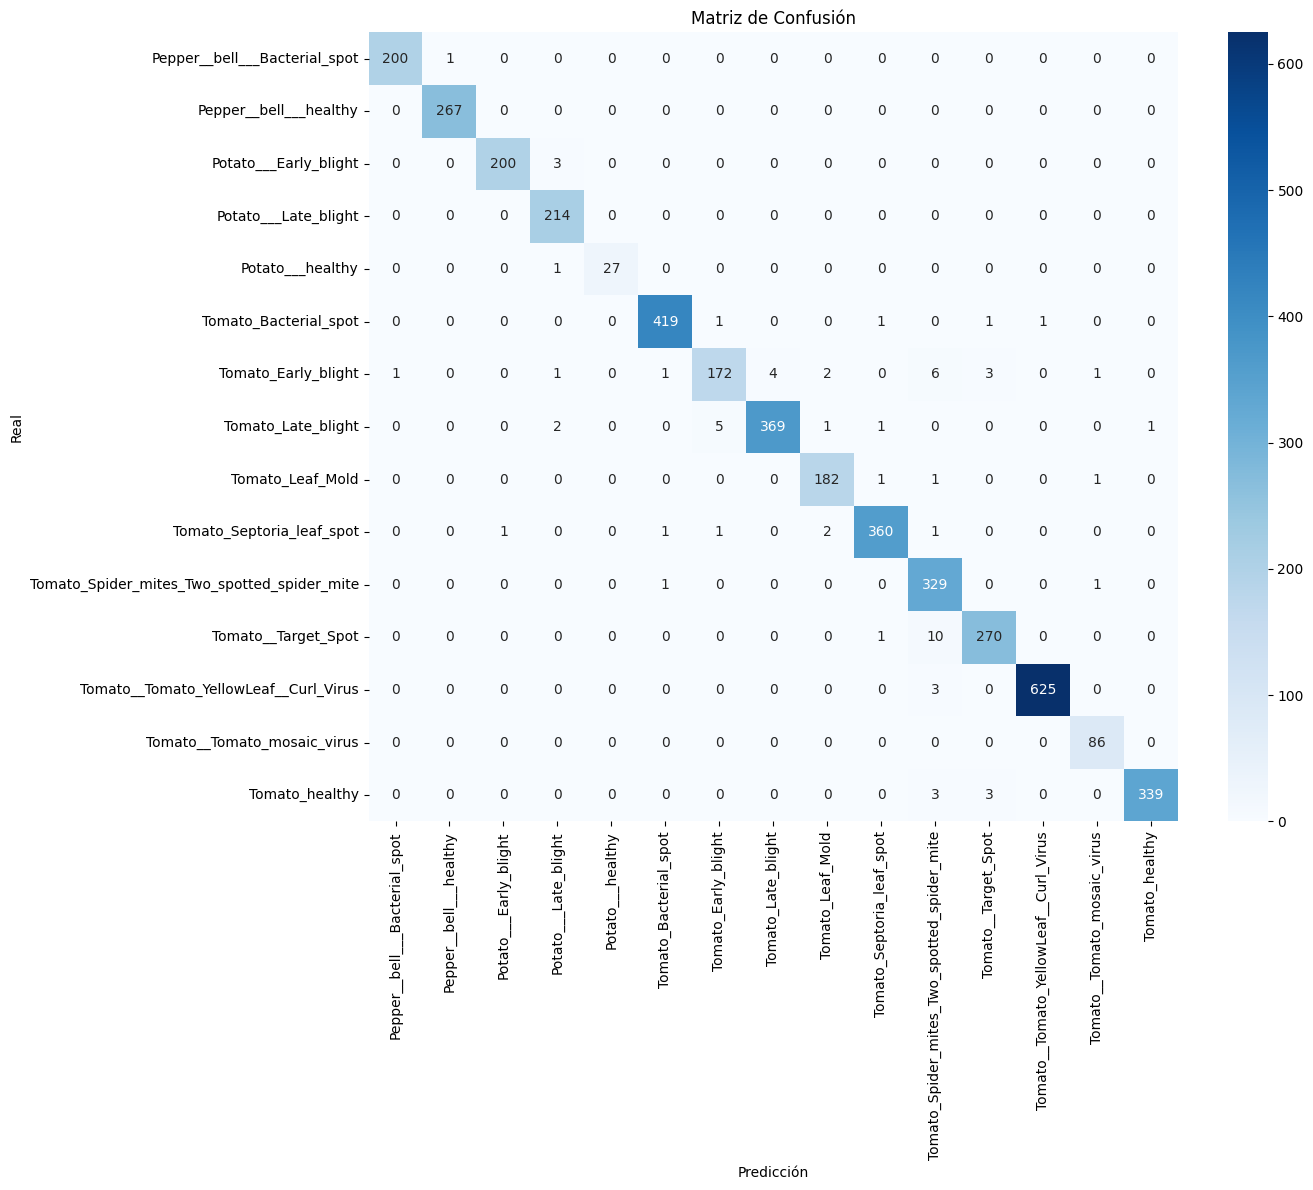

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00       201
                     Pepper__bell___healthy       1.00      1.00      1.00       267
                      Potato___Early_blight       1.00      0.99      0.99       203
                       Potato___Late_blight       0.97      1.00      0.98       214
                           Potato___healthy       1.00      0.96      0.98        28
                      Tomato_Bacterial_spot       0.99      0.99      0.99       423
                        Tomato_Early_blight       0.96      0.90      0.93       191
                         Tomato_Late_blight       0.99      0.97      0.98       379
                           Tomato_Leaf_Mold       0.97      0.98      0.98       185
                  Tomato_Septoria_leaf_spot       0.99      0.98      0.99       366
Tomato_Spider_mites_Two_spotted_spider_mite       0.93      0.99

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

modelo.eval()
todas_predicciones = []
todas_etiquetas = []

with torch.no_grad():
    for imagenes, etiquetas in val_loader:
        imagenes = imagenes.to(device)
        salidas = modelo(imagenes)
        _, predicciones = torch.max(salidas, 1)

        todas_predicciones.extend(predicciones.cpu().numpy())
        todas_etiquetas.extend(etiquetas.numpy())

# Matriz de confusión
cm = confusion_matrix(todas_etiquetas, todas_predicciones)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases, yticklabels=clases)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('matriz_confusion.png')
plt.show()

# Reporte de clasificación
print(classification_report(todas_etiquetas, todas_predicciones, target_names=clases))

## 10. Prueba con imágenes externas (fuera del dataset)

Para evaluar la capacidad real de generalización, probamos el modelo
con imágenes de hojas obtenidas de fuera de PlantVillage.

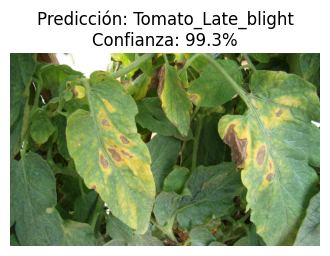

('Tomato_Late_blight', 0.9931851029396057)

In [30]:
from PIL import Image
import requests
from io import BytesIO

def predecir_imagen_url(url, transform, modelo, clases, device):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert('RGB')

    img_tensor = transform(img).unsqueeze(0).to(device)

    modelo.eval()
    with torch.no_grad():
        salida = modelo(img_tensor)
        probs = torch.nn.functional.softmax(salida, dim=1)
        conf, pred = torch.max(probs, 1)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Predicción: {clases[pred.item()]}\nConfianza: {conf.item()*100:.1f}%")
    plt.axis('off')
    plt.show()

    return clases[pred.item()], conf.item()

predecir_imagen_url(
    "https://thfvnext.bing.com/th/id/R.29789dd9e12b81cf8bcdbf9fb8ffe3ae?rik=%2bzAj7oScAL2rfg&pid=ImgRaw&r=0",
    val_transform, modelo, clases, device
)

## 10. Conclusiones

- El modelo alcanzó **98.33% de precisión** en el conjunto de validación
  usando Transfer Learning con ResNet18, fine-tuning de `layer4` y
  data augmentation (10 épocas).

- La combinación de fine-tuning + augmentation mejoró significativamente
  el resultado inicial (88.44% con solo la capa final entrenable y sin
  augmentation), demostrando que descongelar capas profundas permite
  aprovechar mejor la variedad de datos aumentados.

- Las pruebas con imágenes externas (fuera de PlantVillage) mostraron
  buen desempeño en casos visualmente claros, pero menor confianza en
  casos ambiguos o con fondos complejos, revelando una limitación
  esperada de generalización fuera del dominio de entrenamiento.

- Posibles mejoras futuras: incluir imágenes de campo real (ej. dataset
  PlantDoc) durante el entrenamiento, probar arquitecturas más profundas
  (ResNet50), y desarrollar una interfaz de inferencia (Gradio/Hugging
  Face Spaces) para pruebas interactivas.

### Aplicación práctica
Este tipo de modelo podría integrarse en una aplicación móvil que permita
a pequeños agricultores tomar una foto de una hoja y recibir un diagnóstico
preliminar, facilitando la detección temprana de enfermedades en cultivos.
Sin embargo, para uso en campo real sería necesario entrenar con imágenes
en condiciones similares a las que usaría el usuario final.